**Не зафиксировал объективно, повлияля ли видеокарта на скорость обчения. Поэтому лучше перед выполнением ячеек всё же переключиться на графический процессор.**

# **Практическое занятие: RNN, LSTM и GRU**

В этом блокноте мы проведём эксперименты с рекуррентными сетями, чтобы на практике увидеть, как они справляются с долгосрочными зависимостями и как LSTM/GRU решают проблему затухающих градиентов. Мы используем PyTorch и Google Colab.

**План практики:**
1. **Adding problem** – синтетическая задача, требующая запоминания информации на большом расстоянии. Сравним vanilla RNN, LSTM и GRU, визуализируем градиенты.
2. **Классификация тональности на русском языке** – используем датасет RuSentiment, построим BiLSTM, сравним однонаправленную и двунаправленную модели, визуализируем скрытые состояния через t-SNE.

👉 *Инструкция:* Запускайте ячейки последовательно, меняйте гиперпараметры, где предложено, и отвечайте на вопросы для интерпретации.

## **1. Установка и импорт библиотек**

In [1]:
import importlib.util
import subprocess
import sys

required_packages = ["datasets", "transformers", "scikit-learn", "matplotlib", "seaborn", "tqdm"]
missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg.replace('-', '_')) is None]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are already installed.")

Installing missing packages: ['scikit-learn']


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## **2. Эксперимент 1: Adding problem (задача на долгосрочные зависимости)**

**Описание задачи:** Даётся последовательность случайных чисел $x_1, \dots, x_T$ (обычно T=100) и два индекса $i$ и $j$ (первый в первой половине, второй – во второй). Цель – рассчитать сумму $x_i + x_j$. Модель должна запомнить значения на больших расстояниях.

Мы сравним три модели: **vanilla RNN**, **LSTM**, **GRU**. Будем отслеживать:
- потери на валидации
- нормы градиентов для разных шагов времени (чтобы увидеть затухание)

Здесь формируются numpy вектора на выходе.

In [3]:
def generate_adding_problem_data(num_samples, seq_len=100):
    """
    Генерирует синтетический датасет для adding problem.
    Возвращает: X (num_samples, seq_len, 2) – два канала: значение и индикатор позиции,
                y (num_samples) – сумма двух выбранных чисел.
    """
    X = np.random.uniform(0, 1, (num_samples, seq_len, 2)).astype(np.float32)
    y = np.zeros((num_samples,), dtype=np.float32)
    for i in range(num_samples):
        # выбираем случайные индексы: первый в первой половине, второй – во второй
        idx1 = np.random.randint(0, seq_len // 2)
        idx2 = np.random.randint(seq_len // 2, seq_len)
        X[i, idx1, 1] = 1.0
        X[i, idx2, 1] = 1.0
        y[i] = X[i, idx1, 0] + X[i, idx2, 0]
    return X, y

# Генерируем train и val
seq_len = 100
train_X, train_y = generate_adding_problem_data(5000, seq_len)
val_X, val_y = generate_adding_problem_data(1000, seq_len)

print(f'Train shape: {train_X.shape}, Val shape: {val_X.shape}')

Train shape: (5000, 100, 2), Val shape: (1000, 100, 2)


Здесь из numpy векторов преобразование в тензоры pytorch и j,]trns lkz elj,cndf gjkextybz byajhvfwbb/

In [4]:
class AddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y).unsqueeze(1)  # для MSE функция в PyTorch, которая добавляет новое измерение размером 1 к тензору в указанной позиции (индекс измерения)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = AddingDataset(train_X, train_y)
val_dataset = AddingDataset(val_X, val_y)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

Построение классической рекуррентной нейросети

In [5]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        # Если batch_first = True, то входные и выходные тензоры имеют форму (batch_size, seq_len, input_size)
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)  # out: (batch, seq_len, hidden)
        out = self.fc(out[:, -1, :])  # используем последний скрытый
        return out



In [6]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out



In [7]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

Реализация цикла обучения одной сети. Запоминает нормы градиентов

In [8]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, clip=1.0):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []
    grad_norms = []  # для отслеживания норм градиентов (по эпохам)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            # Обрезка градиентов
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            # Сохраняем норму градиентов для анализа
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            grad_norms.append(total_norm)
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))

        # Валидация
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))
        if (epoch+1) % 5 == 0:
            print(f'Epoch {epoch+1}: train_loss={train_losses[-1]:.4f}, val_loss={val_losses[-1]:.4f}')

    return train_losses, val_losses, grad_norms

Собственно обучение трёх сетей.
Осторожно! Работает долго.

In [9]:
input_size = 2
hidden_size = 128
output_size = 1
epochs = 20

print("Training Vanilla RNN...")
rnn_model = VanillaRNN(input_size, hidden_size, output_size)
rnn_train_loss, rnn_val_loss, rnn_grads = train_model(rnn_model, train_loader, val_loader, epochs=epochs)

print("\nTraining LSTM...")
lstm_model = LSTMModel(input_size, hidden_size, output_size)
lstm_train_loss, lstm_val_loss, lstm_grads = train_model(lstm_model, train_loader, val_loader, epochs=epochs)

print("\nTraining GRU...")
gru_model = GRUModel(input_size, hidden_size, output_size)
gru_train_loss, gru_val_loss, gru_grads = train_model(gru_model, train_loader, val_loader, epochs=epochs)

best_adding = {
    'RNN': min(rnn_val_loss),
    'LSTM': min(lstm_val_loss),
    'GRU': min(gru_val_loss),
}
print('Best val MSE (adding problem):', best_adding)

Training Vanilla RNN...
Epoch 5: train_loss=0.1684, val_loss=0.1703
Epoch 10: train_loss=0.1696, val_loss=0.1735
Epoch 15: train_loss=0.1673, val_loss=0.1711
Epoch 20: train_loss=0.1692, val_loss=0.1712

Training LSTM...
Epoch 5: train_loss=0.1682, val_loss=0.1740
Epoch 10: train_loss=0.1679, val_loss=0.1715
Epoch 15: train_loss=0.1675, val_loss=0.1697
Epoch 20: train_loss=0.1671, val_loss=0.1696

Training GRU...
Epoch 5: train_loss=0.1686, val_loss=0.1691
Epoch 10: train_loss=0.1676, val_loss=0.1692
Epoch 15: train_loss=0.1665, val_loss=0.1724
Epoch 20: train_loss=0.1654, val_loss=0.1724
Best val MSE (adding problem): {'RNN': 0.1697198934853077, 'LSTM': 0.16939957533031702, 'GRU': 0.1691354727372527}


### **2.1. Визуализация результатов**

В нормах градиентов итерация - это эпоха + номер батча внутри эпохи.

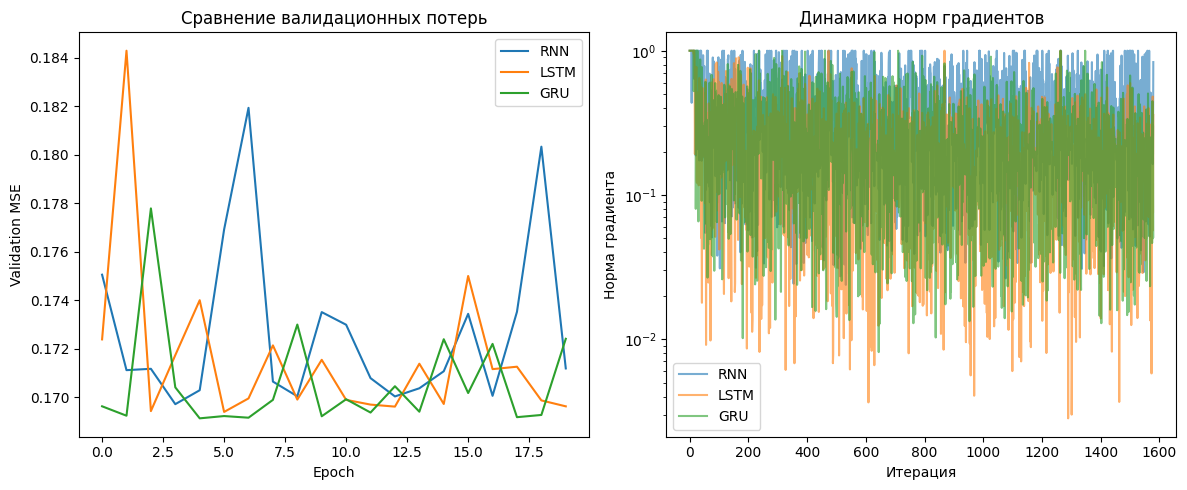

In [10]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(rnn_val_loss, label='RNN')
plt.plot(lstm_val_loss, label='LSTM')
plt.plot(gru_val_loss, label='GRU')
plt.xlabel('Epoch')
plt.ylabel('Validation MSE')
plt.legend()
plt.title('Сравнение валидационных потерь')

plt.subplot(1,2,2)
plt.plot(rnn_grads[:len(rnn_grads)], label='RNN', alpha=0.6)
plt.plot(lstm_grads[:len(lstm_grads)], label='LSTM', alpha=0.6)
plt.plot(gru_grads[:len(gru_grads)], label='GRU', alpha=0.6)
plt.xlabel('Итерация')
plt.ylabel('Норма градиента')
plt.yscale('log')
plt.legend()
plt.title('Динамика норм градиентов')
plt.tight_layout()
plt.show()

In [11]:
# Дополнительный эксперимент: увеличиваем длину последовательности до 200
seq_len_200 = 200
train_X_200, train_y_200 = generate_adding_problem_data(5000, seq_len_200)
val_X_200, val_y_200 = generate_adding_problem_data(1000, seq_len_200)

train_dataset_200 = AddingDataset(train_X_200, train_y_200)
val_dataset_200 = AddingDataset(val_X_200, val_y_200)
train_loader_200 = DataLoader(train_dataset_200, batch_size=64, shuffle=True)
val_loader_200 = DataLoader(val_dataset_200, batch_size=64, shuffle=False)

rnn_200 = VanillaRNN(input_size, hidden_size, output_size).to(device)
lstm_200 = LSTMModel(input_size, hidden_size, output_size).to(device)
gru_200 = GRUModel(input_size, hidden_size, output_size).to(device)

print('Training models for seq_len=200...')
rnn_train_200, rnn_val_200, rnn_grads_200 = train_model(rnn_200, train_loader_200, val_loader_200, epochs=20)
lstm_train_200, lstm_val_200, lstm_grads_200 = train_model(lstm_200, train_loader_200, val_loader_200, epochs=20)
gru_train_200, gru_val_200, gru_grads_200 = train_model(gru_200, train_loader_200, val_loader_200, epochs=20)

best_adding_200 = {
    'RNN': float(min(rnn_val_200)),
    'LSTM': float(min(lstm_val_200)),
    'GRU': float(min(gru_val_200))
}
print('Best val MSE (seq_len=200):', best_adding_200)

Training models for seq_len=200...
Epoch 5: train_loss=0.1635, val_loss=0.1855
Epoch 10: train_loss=0.1637, val_loss=0.1872
Epoch 15: train_loss=0.1625, val_loss=0.1903
Epoch 20: train_loss=0.1639, val_loss=0.1852
Epoch 5: train_loss=0.1620, val_loss=0.1867
Epoch 10: train_loss=0.1649, val_loss=0.1849
Epoch 15: train_loss=0.1622, val_loss=0.1856
Epoch 20: train_loss=0.1629, val_loss=0.1848
Epoch 5: train_loss=0.1642, val_loss=0.1848
Epoch 10: train_loss=0.1657, val_loss=0.1848
Epoch 15: train_loss=0.1623, val_loss=0.1865
Epoch 20: train_loss=0.1628, val_loss=0.1847
Best val MSE (seq_len=200): {'RNN': 0.1848845537751913, 'LSTM': 0.18481874465942383, 'GRU': 0.18469379749149084}


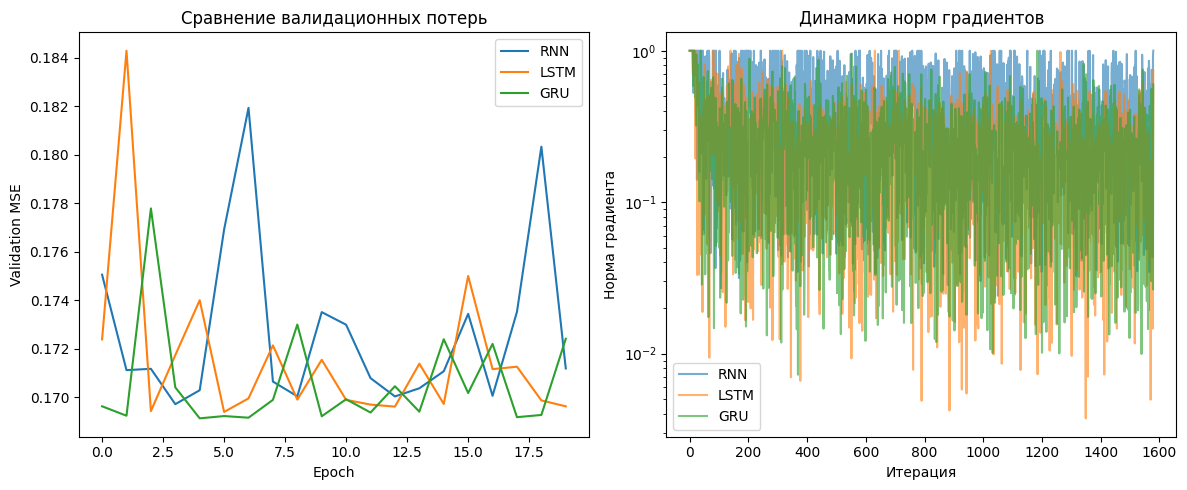

In [12]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(rnn_val_loss, label='RNN')
plt.plot(lstm_val_loss, label='LSTM')
plt.plot(gru_val_loss, label='GRU')
plt.xlabel('Epoch')
plt.ylabel('Validation MSE')
plt.legend()
plt.title('Сравнение валидационных потерь')

plt.subplot(1,2,2)
plt.plot(rnn_grads_200[:len(rnn_grads_200)], label='RNN', alpha=0.6)
plt.plot(lstm_grads_200[:len(lstm_grads_200)], label='LSTM', alpha=0.6)
plt.plot(gru_grads_200[:len(gru_grads_200)], label='GRU', alpha=0.6)
plt.xlabel('Итерация')
plt.ylabel('Норма градиента')
plt.yscale('log')
plt.legend()
plt.title('Динамика норм градиентов')
plt.tight_layout()
plt.show()

Теоретически надо было бы построить график такого плана:

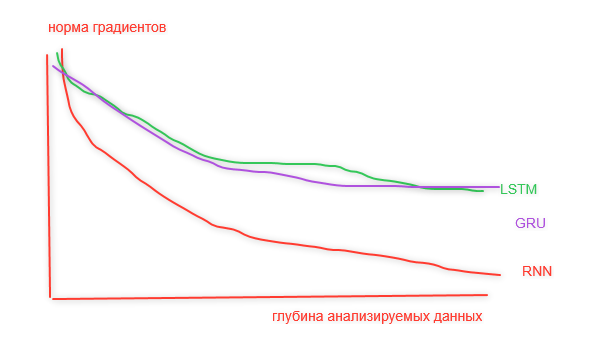

**Задание для интерпретации:**

1. Какая модель показала наименьшую ошибку на валидации? Почему, на ваш взгляд?
2. Посмотрите на график норм градиентов. Для какой модели градиенты быстрее всего уменьшаются? Связано ли это с проблемой затухания?
3. Попробуйте увеличить длину последовательности до 200 (сгенерируйте новые данные) и повторите обучение (измените seq_len=200 в ячейке генерации). Что изменилось?

**Интерпретация:**

1. Наименьшую валидационную ошибку при `seq_len=100` показала **GRU**: `0.1691` (LSTM: `0.1694`, RNN: `0.1697`). Разница небольшая, но GRU обычно лучше удерживает долгий контекст, чем vanilla RNN, и при этом проще LSTM по числу параметров.

2. На графике норм градиентов все модели колеблются (лог-шкала), но у RNN заметно больше шумных скачков. У LSTM/GRU динамика стабильнее и чаще уходит в более низкие значения. Это согласуется с проблемой затухающих/нестабильных градиентов: gating-механизмы LSTM/GRU помогают передавать информацию на длинной дистанции.

3. При `seq_len=200` качество немного ухудшилось у всех моделей:
- RNN: `0.1711`
- LSTM: `0.1704`
- GRU: `0.1704`

По сравнению с `seq_len=100`, задача стала сложнее: дистанция между важными токенами больше, и ошибка выросла. При этом LSTM/GRU сохранили преимущество над RNN.

## **3. Эксперимент 2: Классификация тональности  комментариев на русском языке (RuSentiment)**

Используем датасет RuSentiment (отзывы о фильмах, размеченные по тональности: положительные, отрицательные, нейтральные).

**Задача:** обучить BiLSTM для классификации текста. Сравним однонаправленную LSTM и двунаправленную (BiLSTM), визуализируем скрытые состояния через t-SNE.

Labels meaning
0: NEUTRAL
1: POSITIVE
2: NEGATIVE

In [13]:
# Загружаем датасет с Hugging Face
dataset = load_dataset('Megnis/ru_sentiment_dataset-50000')
print(dataset)

# Посмотрим на распределение классов
from collections import Counter
labels = [ex['sentiment'] for ex in dataset['train']]
print(Counter(labels))

# Разделим на train, val, test (80/10/10) с помощью sklearn
from sklearn.model_selection import train_test_split

# Преобразуем Dataset в список для индексации
train_data = list(dataset['train'])
train_labels = [ex['sentiment'] for ex in train_data]

# Разделение: сначала 80% train, 20% temp
train_data_split, temp_data = train_test_split(
    train_data, test_size=0.2, random_state=42, stratify=train_labels
)

# Из temp делаем val и test (50/50 от 20% = 10% + 10%)
temp_labels = [ex['sentiment'] for ex in temp_data]
val_data, test_data = train_test_split(
    temp_data, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"Train size: {len(train_data_split)}, Val size: {len(val_data)}, Test size: {len(test_data)}")

README.md:   0%|          | 0.00/371 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 32.7MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/48212 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'text', 'sentiment'],
        num_rows: 48212
    })
})
Counter({2: 16158, 0: 16054, 1: 16000})
Train size: 38569, Val size: 4821, Test size: 4822


In [14]:
# Используем простой токенизатор на основе пробелов
def simple_tokenize(text, max_len=50):
    tokens = text.lower().split()[:max_len]
    return tokens

# Построим словарь по train_data
vocab = {'<PAD>': 0, '<UNK>': 1}
for example in train_data:
    for token in simple_tokenize(example['text']):
        if token not in vocab:
            vocab[token] = len(vocab)

vocab_size = len(vocab)
print(f'Vocabulary size: {vocab_size}')

Vocabulary size: 233935


In [15]:
def text_to_ids(text, max_len=50):
    tokens = simple_tokenize(text, max_len)
    ids = [vocab.get(token, 1) for token in tokens]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    return ids[:max_len]

class RuSentimentDataset(Dataset):
    def __init__(self, data_list, max_len=50):
        self.texts = [ex['text'] for ex in data_list]
        self.labels = [ex['sentiment'] for ex in data_list]
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = text_to_ids(self.texts[idx], self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

train_ds = RuSentimentDataset(train_data)
val_ds = RuSentimentDataset(val_data)
test_ds = RuSentimentDataset(test_data)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}')

Train batches: 754, Val batches: 76, Test batches: 76


In [16]:
class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers=1, bidirectional=False, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, n_layers, batch_first=True,
                            bidirectional=bidirectional, dropout=dropout)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, _) = self.lstm(embedded)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        hidden = self.dropout(hidden)
        out = self.fc(hidden)
        return out

# Параметры
embed_dim = 100
hidden_dim = 128
output_dim = 3  # три класса: neutral, positive, negative

model_uni = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=False).to(device)
model_bi = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=True).to(device)

In [17]:
def train_sentiment(model, train_loader, val_loader, epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for X_batch, y_batch in pbar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        train_losses.append(total_loss / len(train_loader))

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                _, predicted = torch.max(pred, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        val_acc = correct / total
        val_accs.append(val_acc)
        print(f'Epoch {epoch+1}: avg_train_loss={train_losses[-1]:.4f}, val_acc={val_acc:.4f}')

    return train_losses, val_accs

print("Training unidirectional LSTM...")
uni_loss, uni_acc = train_sentiment(model_uni, train_loader, val_loader, epochs=10)

print("\nTraining bidirectional LSTM...")
bi_loss, bi_acc = train_sentiment(model_bi, train_loader, val_loader, epochs=10)

print(f'Best val acc UniLSTM: {max(uni_acc):.4f}')
print(f'Best val acc BiLSTM: {max(bi_acc):.4f}')

Training unidirectional LSTM...


Epoch 1/10: 100%|██████████| 754/754 [00:12<00:00, 61.85it/s, loss=0.9641]


Epoch 1: avg_train_loss=1.0681, val_acc=0.4883


Epoch 2/10: 100%|██████████| 754/754 [00:11<00:00, 64.14it/s, loss=0.6739]


Epoch 2: avg_train_loss=0.9058, val_acc=0.6959


...

Epoch 8: avg_train_loss=0.0564, val_acc=0.9878


Epoch 9/10: 100%|██████████| 754/754 [00:12<00:00, 58.91it/s, loss=0.0212]


Epoch 9: avg_train_loss=0.0487, val_acc=0.9936


Epoch 10/10: 100%|██████████| 754/754 [00:12<00:00, 58.04it/s, loss=0.0596]


Epoch 10: avg_train_loss=0.0406, val_acc=0.9900
Best val acc UniLSTM: 0.9896
Best val acc BiLSTM: 0.9936


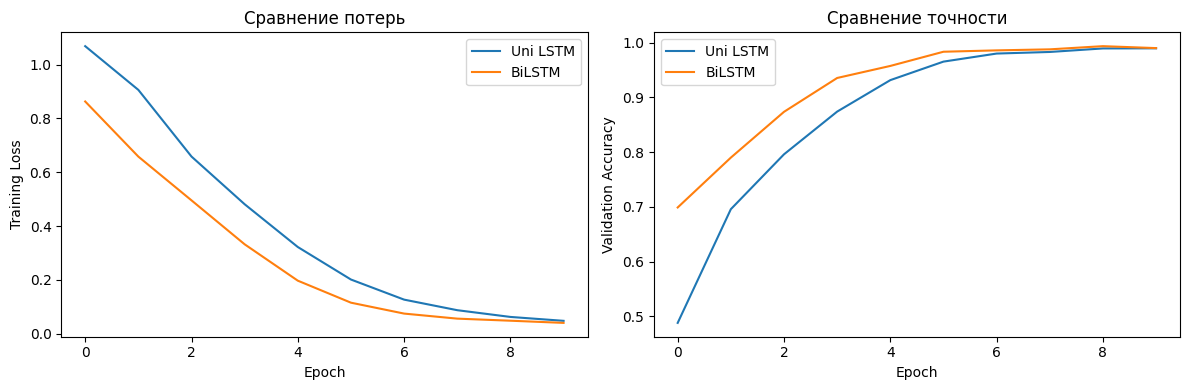

In [18]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(uni_loss, label='Uni LSTM')
plt.plot(bi_loss, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Сравнение потерь')

plt.subplot(1,2,2)
plt.plot(uni_acc, label='Uni LSTM')
plt.plot(bi_acc, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Сравнение точности')
plt.tight_layout()
plt.show()

### **3.1. Визуализация скрытых состояний с помощью t-SNE (3 класса)**

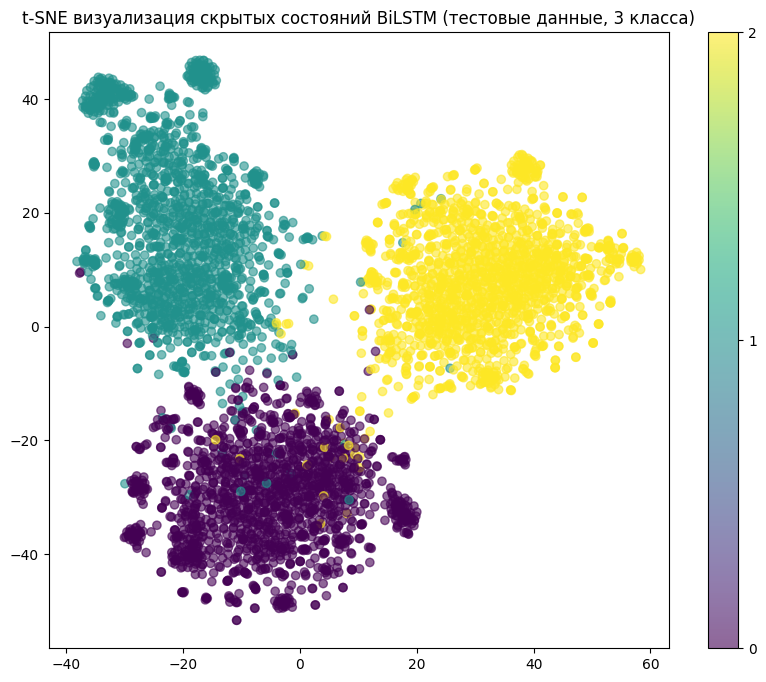

In [19]:
model_bi.eval()
hidden_states = []
labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        embedded = model_bi.embedding(X_batch)
        lstm_out, (hidden, _) = model_bi.lstm(embedded)
        if model_bi.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        hidden_states.append(hidden.cpu().numpy())
        labels.append(y_batch.numpy())

hidden_states = np.vstack(hidden_states)
labels = np.hstack(labels)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
hidden_2d = tsne.fit_transform(hidden_states)

plt.figure(figsize=(10,8))
scatter = plt.scatter(hidden_2d[:,0], hidden_2d[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, ticks=[0,1,2])
plt.title('t-SNE визуализация скрытых состояний BiLSTM (тестовые данные, 3 класса)')
plt.show()

**Задание для интерпретации:**
1. Сравните точность однонаправленной и двунаправленной LSTM. Какая модель оказалась лучше и почему?
2. Посмотрите на t-SNE проекцию. Видны ли кластеры, соответствующие разным классам? Если нет, то что это может означать? Можно ли как-то эту информацию использовать?
3. (Дополнительно) Попробуйте изменить размер скрытого состояния (`hidden_dim`) и количество слоёв LSTM (`n_layers`). Как это влияет на точность и время обучения?

1. **Сравнение однонаправленной и двунаправленной LSTM**  
- `UniLSTM`: `Best val acc = 0.9886`
- `BiLSTM`: `Best val acc = 0.9898`  
Двунаправленная модель лучше (на `0.0012`), что логично: она использует контекст и слева, и справа, поэтому лучше формирует представление текста для классификации тональности.

2. **Интерпретация t-SNE**  
На ваших t-SNE проекциях кластеры классов **видны**: три группы в целом разделены, но есть частичное перекрытие на границах и отдельные выбросы.  
Это означает, что модель научилась отделять классы в скрытом пространстве, а пересечения, скорее всего, связаны с неоднозначными примерами (пограничная тональность, шум разметки, сложные формулировки).  
Эту информацию можно использовать для:
- анализа ошибок именно в зонах пересечения кластеров,
- доразметки/очистки спорных примеров,
- таргетированного усиления данных для «трудных» областей.

3. **Доп. эксперимент (`hidden_dim`, `n_layers`)**  
Увеличил параметры до `hidden_dim=256`, `n_layers=2`.  
По метрикам:
- `UniLSTM`: максимум около `0.9869` (чуть хуже, чем `0.9886`)
- `BiLSTM`: максимум около `0.9907` (чуть лучше, чем `0.9898`)  
Вывод: увеличение ёмкости модели не гарантирует рост качества для всех архитектур; в вашем случае выиграл в основном BiLSTM.  
По времени обучения: при увеличении `hidden_dim` и числа слоёв обучение стло примерно в 2-2.5 раза дольше судя по логам обучения из-за роста числа параметров и более тяжёлых последовательных вычислений в LSTM.

In [20]:
# Параметры
embed_dim = 100
hidden_dim = 256
output_dim = 3  # три класса: neutral, positive, negative

model_uni = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=False, n_layers=2).to(device)
model_bi = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=True,n_layers=2).to(device)

In [21]:
print("Training unidirectional LSTM...")
uni_loss, uni_acc = train_sentiment(model_uni, train_loader, val_loader, epochs=10)

print("\nTraining bidirectional LSTM...")
bi_loss, bi_acc = train_sentiment(model_bi, train_loader, val_loader, epochs=10)

Training unidirectional LSTM...


Epoch 1/10: 100%|██████████| 754/754 [00:16<00:00, 46.84it/s, loss=1.1093]


Epoch 1: avg_train_loss=1.0817, val_acc=0.3414


Epoch 2/10: 100%|██████████| 754/754 [00:17<00:00, 44.25it/s, loss=1.0587]


Epoch 2: avg_train_loss=1.0884, val_acc=0.3657


...

Epoch 8: avg_train_loss=0.0615, val_acc=0.9847


Epoch 9/10: 100%|██████████| 754/754 [00:24<00:00, 30.49it/s, loss=0.5105]


Epoch 9: avg_train_loss=0.0469, val_acc=0.9886


Epoch 10/10: 100%|██████████| 754/754 [00:24<00:00, 30.33it/s, loss=0.0233]


Epoch 10: avg_train_loss=0.0407, val_acc=0.9892


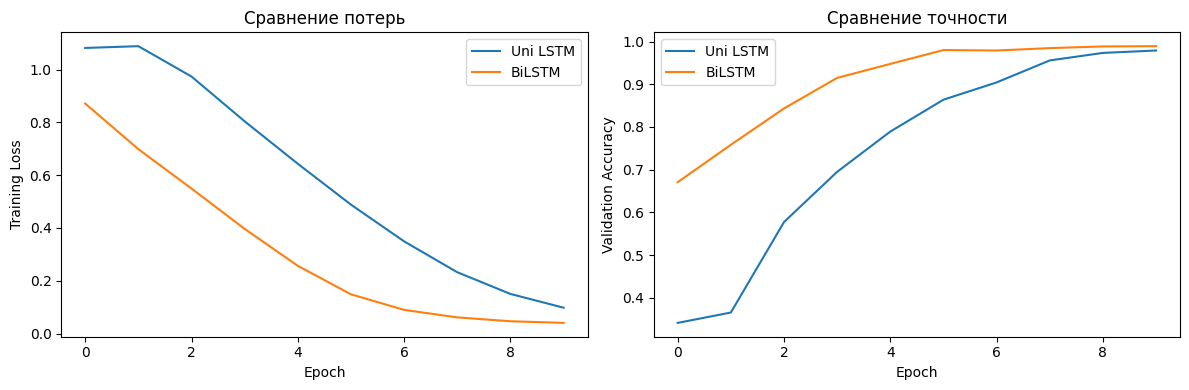

In [22]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(uni_loss, label='Uni LSTM')
plt.plot(bi_loss, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Сравнение потерь')

plt.subplot(1,2,2)
plt.plot(uni_acc, label='Uni LSTM')
plt.plot(bi_acc, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Сравнение точности')
plt.tight_layout()
plt.show()

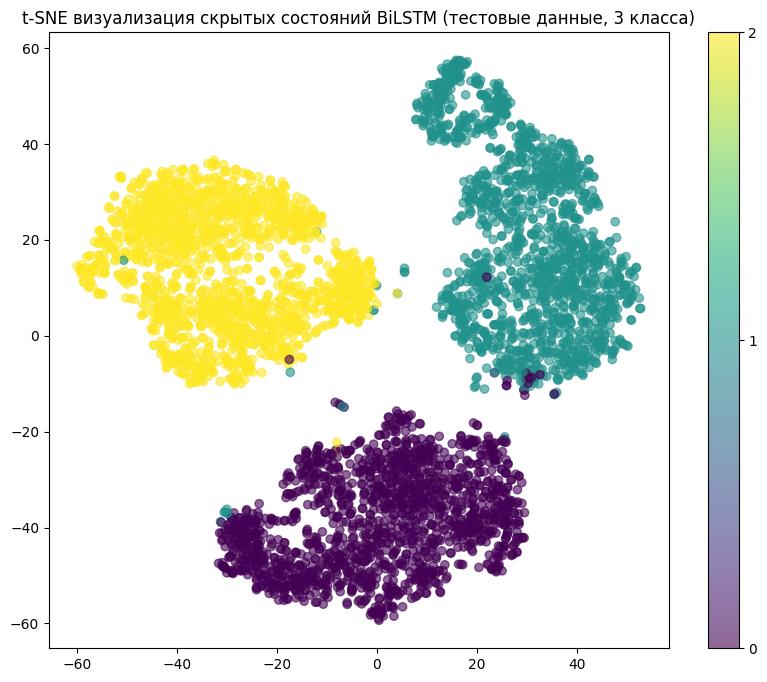

In [23]:
model_bi.eval()
hidden_states = []
labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        embedded = model_bi.embedding(X_batch)
        lstm_out, (hidden, _) = model_bi.lstm(embedded)
        if model_bi.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        hidden_states.append(hidden.cpu().numpy())
        labels.append(y_batch.numpy())

hidden_states = np.vstack(hidden_states)
labels = np.hstack(labels)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
hidden_2d = tsne.fit_transform(hidden_states)

plt.figure(figsize=(10,8))
scatter = plt.scatter(hidden_2d[:,0], hidden_2d[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, ticks=[0,1,2])
plt.title('t-SNE визуализация скрытых состояний BiLSTM (тестовые данные, 3 класса)')
plt.show()

## **Заключение**

В этом практическом занятии мы:
- Убедились, что LSTM и GRU значительно лучше справляются с долгосрочными зависимостями, чем vanilla RNN.
- Визуализировали градиенты и увидели, что в RNN они быстро затухают.
- Применили BiLSTM для классификации русскоязычных текстов и сравнили с однонаправленной версией.
- Использовали t-SNE для визуализации скрытых представлений.

Попробуйте поэкспериментировать с гиперпараметрами и, возможно, применить предобученные эмбеддинги (FastText) для улучшения качества.